# Optimizer comparision

In this project, we will compare some popular optimizers, and explain the math and formulas behind these techniques, before test them in some interesting functions

## What optimizers are?

The optimizers, are iterative methods used to try to minimize a cost function, reaching a minimum. These methods are based on mathematical concepts, such as the gradient. They are used in machine learning, because they provide benefits when optimizing a function and finding the best parameters for our model.

Here we will discuss about the main ones, as well as explain and test them in complex functions. We will cover Momentum, Adam, AdaGrad, RSMProp, Newton, SGD, and Conjugated Gradient. As we will see, they are extremely useful with convex functions, but they also can work for non convex functions 

## Functions to optimize

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
def himmelblau(w):
    return (w[0]**2 + w[1] - 11) ** 2 + (w[0] + w[1] ** 2 - 7)**2

def rosenbrock(w, a=1., b=100.):
    return (a - w[0]) ** 2 + b * (w[1] - w[0] ** 2) ** 2

def beale(w):
    return (3/2 - w[0] + w[0] * w[1]) ** 2 + (9/4 - w[0] + w[0] * w[1] ** 2) ** 2 + (21/8 - w[0] + w[0] * w[1] ** 3) ** 2

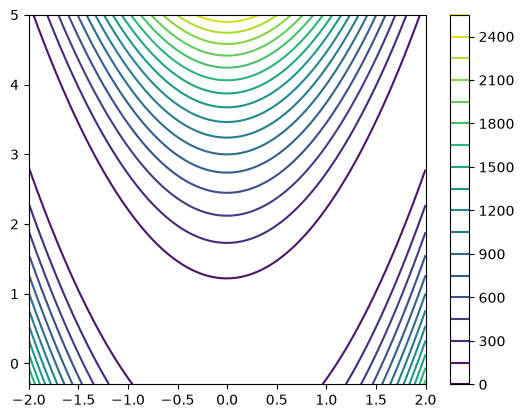

In [12]:

xlist = np.linspace(-2.0, 2.0, 100)
ylist = np.linspace(-0.3, 5.0, 100)
X, Y = np.meshgrid(xlist, ylist)

Z = np.zeros([100, 100])
for i in range(0, 100):
    for j in range(0, 100):
        w = [X[i, j], Y[i, j]]
        Z[i, j] = rosenbrock(w)

fig, ax = plt.subplots(1, 1)

cp = ax.contour(X, Y, Z, levels = 20)
fig.colorbar(cp)

plt.show()

## Optimizers

### SGD

The Stochastic Gradient Descent is a optimization method that seek for the best path each iteration. The best path will be defined by the gradient of the cost function. So we want to move in the direction that more decreases the cost function value, based on just one instance, randomly chosen. But we will do it, in a way that each epoch (with n iterations, n = num of instances) will update the step using one and just one time each instance. This way, our opimizer will move a little randomly, and making some random jumps, but in general moving towards a minimum (global or local)

In [27]:
def SGD(X, y, f, grad, batch_size=16, alpha=0.1, max_iter=100, tol=1e-3):
    n_samples, n_features = X.shape
    w = np.zeros(n_features)
    steps = [w.copy()]
    losses = []

    for epoch in range(max_iter):
        loss_epochs = []

        idx = np.random.permutation(n_samples)
        X_shuffled = X[idx]
        y_shuffled = y[idx]

        for i in range(0, n_samples, batch_size):
            X_batch = X_shuffled[i : i + batch_size]
            y_batch = y_shuffled[i : i + batch_size]

            grad_w = grad(w, X_batch, y_batch)
            w = w - alpha * grad_w

            total_loss = f(w, X_batch, y_batch)
            loss_epochs.append(total_loss)

            if np.linalg.norm(grad_w) < tol: 
                break
                
        
        losses.append(np.mean(loss_epochs))
        steps.append(w.copy())

        return np.asarray(steps), w, losses

In [28]:
# MSE
def mse_grad(w, x, y_true):
  grad = x.T @ (x @ w - y_true)
  return grad

def mse(w, x, y_true):
  return 1/2 * np.linalg.norm(y_true - x @ w) ** 2

n = 1000
X = 2 * np.random.rand(n, 1)
y = 4 + 3 * X[:, 0] + np.random.randn(n)

# hacemos la optimización del bias y los pesos todos juntos
X = np.column_stack((X, np.ones(n)))

steps, w, losses = SGD(X, y, mse, mse_grad, alpha=0.01, max_iter=100, batch_size=10, tol=1e-3)
print(w)


[3.12618623 3.85677544]


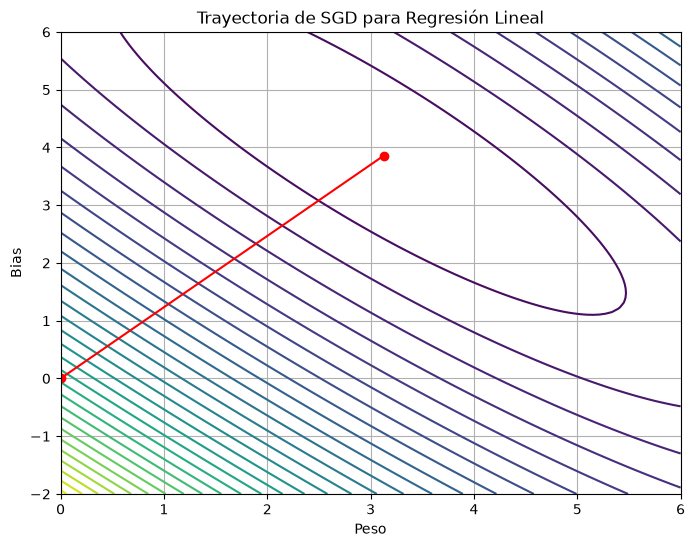

In [29]:
# @title
# no me modifiques :)
def plot_sgd_regresion(all_steps):
  w0_vals = np.linspace(0, 6, 100)
  w1_vals = np.linspace(-2, 6, 100)
  W0, W1 = np.meshgrid(w0_vals, w1_vals)
  Z = np.zeros_like(W0)

  for i in range(W0.shape[0]):
    for j in range(W0.shape[1]):
      w = np.array([W0[i, j], W1[i, j]])
      preds = X @ w
      Z[i, j] = np.mean((preds - y)**2)

  plt.figure(figsize=(8,6))
  plt.contour(W0, W1, Z, levels=30, cmap='viridis')
  plt.xlabel('Peso')
  plt.ylabel('Bias')

  w0_traj = all_steps[:, 0]
  w1_traj = all_steps[:, 1]
  plt.plot(w0_traj, w1_traj, 'o-', color='red')
  plt.title('Trayectoria de SGD para Regresión Lineal')
  plt.grid()
  plt.show()

plot_sgd_regresion(steps)